# Sección F — Ingeniería de características (incisos 28 a 31)
**Responsable:** Melanie

**Propósito:** crear tres dimensiones nuevas a partir de las existentes `Antigüedad`, `Precio_por_Km` y `Vehiculo_Antiguo` que expresen información útil para el análisis del precio de los autos usados, documentando su significado, fórmula y procedimiento, y comprobando con ejemplos que sus valores son correctos.

**Insumo:** `data/processed/cardekho_codificado.csv` (resultado de la Sección E).

**¿Qué hace esta celda?** Prepara las herramientas y carga los datos.
- `numpy` se importa porque da el logaritmo (`np.log`) y el valor "vacío" `NaN`; `pandas` maneja la tabla; `matplotlib` dibuja las figuras.
- `caracteristicas` (alias `fc`) es nuestro módulo en `src/`: ahí están escritas **una sola vez** las fórmulas de esta parte, para que cualquiera del equipo las pueda reutilizar y revisar.
- `eda` es el módulo de Ricardo: se reutiliza para que todas las figuras del reporte tengan el mismo estilo y colores.
- Se guarda el tamaño inicial para comprobar al final que no se perdieron filas.

In [1]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Importación de librerías, módulos propios y carga del
#              dataset de la Sección E.
# Insumo:      data/processed/cardekho_codificado.csv
# Resultado:   DataFrame df.
# ===========================================================
import sys                        # Para indicarle a Python dónde están nuestros módulos (carpeta src)
import numpy as np                # Para el logaritmo (np.log) y el valor vacío NaN
import pandas as pd               # Para manejar la tabla de datos (DataFrame)
import matplotlib.pyplot as plt   # Para dibujar las figuras
import matplotlib.ticker as mticker  # Para dar formato a los números de los ejes

# Nuestros módulos viven en la carpeta "src"; la agregamos a las rutas de búsqueda
sys.path.append("src")
import caracteristicas as fc  # Fórmulas de las Secciones E (25-26) y F
import eda                    # Estilo, colores y utilidades de gráficas (Sección A, Ricardo)

eda.configurar_estilo()                     # Mismo estilo visual en todas las figuras del reporte
pd.set_option("display.max_columns", 80)    # Mostrar todas las columnas sin "..."
pd.set_option("display.width", 200)         # Tablas anchas sin cortes de línea

df = pd.read_csv("data/processed/cardekho_codificado.csv", encoding="utf-8-sig")
filas_iniciales = len(df)
print(df.shape)

(15244, 70)


## F.28 Antigüedad

**¿Qué hace esta celda?** Calcula cuántos años tenía cada auto.
**¿Por qué 2021 como referencia?** Es el año en que se publicaron los anuncios. El precio se fijó en ese momento, así que la edad que importa es la que tenía el auto **entonces**. Si usáramos 2026, todos tendrían 5 años de más que no influyeron en su precio.

In [2]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Creación de Antigüedad = año de referencia - Año
#              (inciso 28).
# Insumo:      df, fc.ANIO_REFERENCIA
# Resultado:   Dimensión Antigüedad en df.
# ===========================================================
print("Año de referencia:", fc.ANIO_REFERENCIA)
print("Año de fabricación: de", df["Año"].min(), "a", df["Año"].max())

# Antigüedad = 2021 - Año  (ejemplo: auto de 2012 -> 9 años)
df["Antigüedad"] = fc.crear_antiguedad(df["Año"])

print(df[["Nombre", "Año", "Antigüedad"]].head(5), "\n")
df["Antigüedad"].describe().round(2)

Año de referencia: 2021
Año de fabricación: de 1992 a 2021
          Nombre   Año  Antigüedad
0    Maruti Alto  2012           9
1  Hyundai Grand  2016           5
2    Hyundai i20  2010          11
3    Maruti Alto  2012           9
4  Ford Ecosport  2015           6 



count    15244.00
mean         6.04
std          3.02
min          0.00
25%          4.00
50%          6.00
75%          8.00
max         29.00
Name: Antigüedad, dtype: float64

**¿Qué hace esta celda?** Cuenta cuántos autos hay de cada antigüedad y calcula su precio mediano.
**¿Para qué?** Para comprobar que la nueva columna es útil: si el precio baja conforme el auto es más viejo, `Antigüedad` ayuda a explicar el precio. Se usa la **mediana** porque los autos de lujo distorsionan la media.

In [3]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Distribución de Antigüedad y precio mediano por año de
#              antigüedad (inciso 28).
# Insumo:      df
# Resultado:   Tabla tabla_antig.
# ===========================================================
tabla_antig = (df.groupby("Antigüedad")
                .agg(Año=("Año", "first"), Registros=("Antigüedad", "size"),
                     Precio_Mediano=("Precio_Venta", "median")))
tabla_antig["% Registros"] = (tabla_antig["Registros"] / len(df) * 100).round(2)
tabla_antig

,Año,Registros,Precio_Mediano,% Registros
Antigüedad,,,,
0,2021,4,525000.0,0.03
1,2020,221,750000.0,1.45
2,2019,1135,820000.0,7.45
3,2018,1896,748000.0,12.44
4,2017,2220,695500.0,14.56
5,2016,2094,600000.0,13.74
6,2015,1904,550000.0,12.49
7,2014,1427,500000.0,9.36
8,2013,1271,450000.0,8.34


### Justificación
Antigüedad (inciso 28): se calculó como `Antigüedad = 2021 − Año`. **Año de referencia: 2021**, el año en que se recolectó y publicó el dataset en Kaggle; es el mismo año con el que se derivó `Año` (observación 1), así que la operación devuelve exactamente la edad que el vehículo tenía cuando se publicó el anuncio. Se eligió 2021 y no el año actual (2026) porque el precio se fijó en el momento del anuncio: con 2026 todos los autos sumarían 5 años que no influyeron en su precio, y un auto de 2021 aparecería con 5 años en lugar de 0.

La antigüedad va de 0 a 29 años, con mediana de 6. La tabla muestra que el precio mediano baja conforme aumenta la antigüedad, lo que confirma que es una característica útil para explicar el precio.

## F.29 Precio_por_Km

**¿Qué hace esta celda?** Antes de dividir entre `Kilómetros` revisamos si hay ceros, porque **dividir entre 0 no está definido** (Python daría infinito).
En nuestro dataset no hay ceros, pero el PDF pide tratarlos. Por eso probamos la regla con 3 valores inventados, uno con 0 km, y mostramos que ese caso queda vacío (`NaN`) en lugar de infinito.

In [4]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Identificación de registros con Kilómetros = 0 y prueba
#              de la regla que los trata (inciso 29).
# Insumo:      df, módulo caracteristicas
# Resultado:   Conteo de ceros y tabla prueba.
# ===========================================================
km_cero = (df["Kilómetros"] == 0).sum()
print("Registros con Kilómetros = 0:", km_cero)
print("Kilómetros mínimo           :", df["Kilómetros"].min())
print("Kilómetros menores a 1,000  :", (df["Kilómetros"] < 1000).sum(), "\n")

# Prueba de la regla con valores de ejemplo (NO son del dataset) que sí incluyen 0 km
prueba = pd.DataFrame({"Precio_Venta": [500_000, 300_000, 800_000],
                       "Kilómetros": [50_000, 0, 20_000]})
prueba["Precio_por_Km"] = fc.crear_precio_por_km(prueba["Precio_Venta"], prueba["Kilómetros"])
print("Prueba de la regla para Kilómetros = 0:")
prueba

Registros con Kilómetros = 0: 0
Kilómetros mínimo           : 100
Kilómetros menores a 1,000  : 2 

Prueba de la regla para Kilómetros = 0:


,Precio_Venta,Kilómetros,Precio_por_Km
0,500000,50000,10.0
1,300000,0,NaN
2,800000,20000,40.0


**¿Qué hace esta celda?** Calcula cuántas rupias vale el auto por cada kilómetro recorrido.
Se muestran los 5 valores más altos para entender los extremos: son autos caros con muy pocos kilómetros.

In [5]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Creación de Precio_por_Km = Precio_Venta / Kilómetros
#              (inciso 29).
# Insumo:      df, módulo caracteristicas
# Resultado:   Dimensión Precio_por_Km en df.
# ===========================================================
# Precio_por_Km = Precio_Venta / Kilómetros; si Kilómetros = 0 la función deja NaN
df["Precio_por_Km"] = fc.crear_precio_por_km(df["Precio_Venta"], df["Kilómetros"])

# 0 nulos confirma que ningún registro cayó en el caso de 0 km
print("Nulos en Precio_por_Km:", df["Precio_por_Km"].isnull().sum())
print(df["Precio_por_Km"].describe().round(2), "\n")

print("Valores más altos (pocos kilómetros y precio alto):")
df.nlargest(5, "Precio_por_Km")[["Nombre", "Precio_Venta", "Kilómetros", "Precio_por_Km"]]

Nulos en Precio_por_Km: 0
count    15244.00
mean        32.85
std        144.79
min          0.32
25%          6.40
50%         11.82
75%         25.71
max      10394.74
Name: Precio_por_Km, dtype: float64 

Valores más altos (pocos kilómetros y precio alto):


,Nombre,Precio_Venta,Kilómetros,Precio_por_Km
3785,Ferrari GTC4Lusso,39500000,3800,10394.736842
10870,Rolls-Royce Ghost,24200000,5000,4840.000000
6174,Mercedes-Benz E-Class,5743000,1198,4793.823038
1449,Hyundai Santro,475000,100,4750.000000
310,BMW Z4,8250000,2000,4125.000000


**¿Qué hace esta celda?** Dibuja la Figura F.2. El eje X está en **escala logarítmica** (1, 10, 100, 1000…) **ya que** los valores van de 0.3 a más de 10,000: en escala normal casi todos los autos quedarían amontonados en una sola barra.
La línea punteada marca la mediana, el valor "típico".

Guardada en: figuras\figura_F2_precio_por_km.png


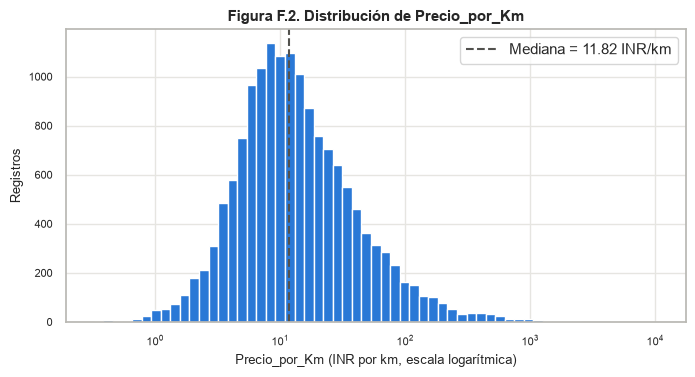

In [6]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Figura F.2: distribución de Precio_por_Km en escala
#              logarítmica (inciso 29).
# Insumo:      df
# Resultado:   figuras/figura_F2_precio_por_km.png
# ===========================================================
fig, eje = plt.subplots(figsize=(8, 3.8))
# logspace crea barras del mismo ancho en escala logarítmica (de 0.3 a 10,000);
# con barras normales casi todo caería en la primera barra
bins = np.logspace(np.log10(df["Precio_por_Km"].min()), np.log10(df["Precio_por_Km"].max()), 60)
eje.hist(df["Precio_por_Km"], bins=bins, color=eda.COLOR_PRINCIPAL)
eje.set_xscale("log")
eje.axvline(df["Precio_por_Km"].median(), color=eda.COLOR_TEXTO, linestyle="--",
            label=f"Mediana = {df['Precio_por_Km'].median():.2f} INR/km")
eje.set_xlabel("Precio_por_Km (INR por km, escala logarítmica)")
eje.set_ylabel("Registros")
eje.legend()
eje.set_title("Figura F.2. Distribución de Precio_por_Km")
print("Guardada en:", eda.guardar_figura(fig, "figura_F2_precio_por_km.png"))
plt.show()

### Justificación
Precio_por_Km (inciso 29): se calculó como `Precio_por_Km = Precio_Venta / Kilómetros`, en rupias por kilómetro recorrido. Indica cuánto vale el auto por cada kilómetro de uso: un valor alto corresponde a autos caros o con pocos kilómetros.

**Tratamiento de `Kilómetros = 0`:** dividir entre cero no está definido. La regla programada en `crear_precio_por_km` divide solo cuando `Kilómetros > 0` y en otro caso deja `NaN` (dato no calculable). No se usa infinito, porque rompería medias, desviaciones y gráficas, ni 0, porque diría que el auto no vale nada por kilómetro, lo cual es falso. La prueba con valores de ejemplo muestra que el caso de 0 km queda en `NaN`. En el dataset **no hay registros con 0 km** (el mínimo es 100 km), así que la regla no modificó ningún registro y no se generaron nulos; la regla se deja programada para que el proceso sea correcto con otros datos.

La distribución es muy asimétrica (Figura F.2, en escala logarítmica): la mediana es de unas 12 INR/km, pero los autos de lujo con pocos kilómetros alcanzan miles (Ferrari GTC4Lusso con 3,800 km: 10,395 INR/km). Por eso conviene describirla con la mediana y no con la media.

## F.30 Vehiculo_Antiguo

**¿Qué hace esta celda?** Antes de elegir el umbral de "auto antiguo", compara varios candidatos (5, 8, 10, 12 y 15 años) y cuántos autos quedarían como antiguos con cada uno.
**¿Para qué?** Para que el umbral se justifique con datos y no se elija al azar.

In [7]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Comparación de umbrales candidatos con la distribución
#              de Antigüedad (inciso 30).
# Insumo:      df
# Resultado:   Tabla umbrales.
# ===========================================================
# Proporción de autos que quedarían como antiguos con distintos umbrales
umbrales = pd.DataFrame({u: {"Registros antiguos": (df["Antigüedad"] >= u).sum(),
                             "% antiguos": round((df["Antigüedad"] >= u).mean() * 100, 2)}
                         for u in [5, 8, 10, 12, 15]}).T
umbrales.index.name = "Umbral (años)"
print("Cuartiles de Antigüedad:", df["Antigüedad"].quantile([0.25, 0.5, 0.75, 0.9]).to_dict(), "\n")
umbrales

Cuartiles de Antigüedad: {0.25: 4.0, 0.5: 6.0, 0.75: 8.0, 0.9: 10.0} 



,Registros antiguos,% antiguos
Umbral (años),,
5,9768.0,64.08
8,4343.0,28.49
10,2057.0,13.49
12,810.0,5.31
15,154.0,1.01


**¿Qué hace esta celda?** Crea la columna 0/1 con el umbral elegido (10 años) y compara los dos grupos.
**¿Para qué la comparación?** Si los antiguos tienen un precio muy distinto al de los demás, la nueva columna separa dos grupos con sentido.

In [8]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Creación de Vehiculo_Antiguo (1 si Antigüedad >= umbral)
#              y comparación entre grupos (inciso 30).
# Insumo:      df, fc.UMBRAL_ANTIGUO
# Resultado:   Dimensión Vehiculo_Antiguo en df y tabla grupos.
# ===========================================================
# Vehiculo_Antiguo = 1 si Antigüedad >= 10 años (fc.UMBRAL_ANTIGUO), 0 si no.
# El umbral es una constante del módulo: si el equipo decide otro, solo se cambia allí.
df["Vehiculo_Antiguo"] = fc.crear_vehiculo_antiguo(df["Antigüedad"])

# Comparación de los dos grupos: tamaño, rango de antigüedad, precio y kilometraje

print("Umbral:", fc.UMBRAL_ANTIGUO, "años")
grupos = (df.groupby("Vehiculo_Antiguo")
            .agg(Registros=("Vehiculo_Antiguo", "size"),
                 Antig_min=("Antigüedad", "min"), Antig_max=("Antigüedad", "max"),
                 Precio_Medio=("Precio_Venta", "mean"), Precio_Mediano=("Precio_Venta", "median"),
                 Km_Mediano=("Kilómetros", "median")))
grupos["% Registros"] = (grupos["Registros"] / len(df) * 100).round(2)
grupos.round(0)

Umbral: 10 años


,Registros,Antig_min,Antig_max,Precio_Medio,Precio_Mediano,Km_Mediano,% Registros
Vehiculo_Antiguo,,,,,,,
0,13187,0,9,834916.0,600000.0,47000.0,87.0
1,2057,10,29,388676.0,275000.0,70000.0,13.0


**¿Qué hace esta celda?** Dibuja la Figura F.1: un histograma de antigüedad donde las barras naranjas son los autos que quedan como antiguos (1) y las azules los que no (0).
La línea punteada va en 9.5 para que quede **entre** las barras de 9 y 10 años.

Guardada en: figuras\figura_F1_antiguedad_umbral.png


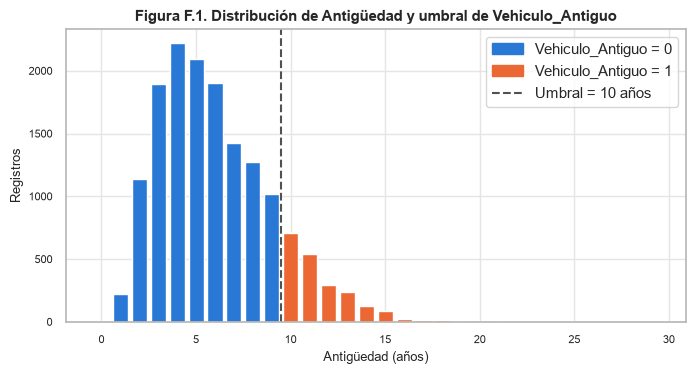

In [9]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Figura F.1: distribución de Antigüedad con el umbral
#              de Vehiculo_Antiguo (inciso 30).
# Insumo:      df, fc.UMBRAL_ANTIGUO
# Resultado:   figuras/figura_F1_antiguedad_umbral.png
# ===========================================================
fig, eje = plt.subplots(figsize=(8, 3.8))
conteo = df["Antigüedad"].value_counts().sort_index()   # Autos por cada año de antigüedad
# Naranja = antiguos (>= umbral), azul = no antiguos
colores = [eda.COLOR_PRECIO if a >= fc.UMBRAL_ANTIGUO else eda.COLOR_PRINCIPAL for a in conteo.index]
eje.bar(conteo.index, conteo.values, color=colores)
eje.axvline(fc.UMBRAL_ANTIGUO - 0.5, color=eda.COLOR_TEXTO, linestyle="--",
            label=f"Umbral = {fc.UMBRAL_ANTIGUO} años")
eje.set_xlabel("Antigüedad (años)")
eje.set_ylabel("Registros")
eje.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=eda.COLOR_PRINCIPAL, label="Vehiculo_Antiguo = 0"),
                    plt.Rectangle((0, 0), 1, 1, color=eda.COLOR_PRECIO, label="Vehiculo_Antiguo = 1"),
                    eje.get_lines()[0]])
eje.set_title("Figura F.1. Distribución de Antigüedad y umbral de Vehiculo_Antiguo")
print("Guardada en:", eda.guardar_figura(fig, "figura_F1_antiguedad_umbral.png"))
plt.show()

### Justificación
Vehiculo_Antiguo (inciso 30): vale **1 si `Antigüedad ≥ 10` años** y 0 en otro caso. El umbral de **10 años** se eligió por tres razones:
1. **Distribución de los datos:** el 75 % de los autos tiene 8 años o menos (Q3 = 8) y el percentil 90 es 10. Con 10 años quedan como antiguos 2,057 autos (13.49 %), es decir, la cola de autos claramente más viejos que el resto (Figura F.1). Con 8 años serían el 28.5 %, casi un tercio del mercado, lo que no corresponde a algo "antiguo"; con 15 años solo el 1 %, demasiado pocos para analizar.
2. **Contexto del mercado indio:** en Delhi-NCR, la región de mayor venta de autos usados de la India, la normativa (orden del National Green Tribunal de 2015, ratificada por la Corte Suprema en 2018) prohíbe circular a vehículos diésel de más de 10 años. A partir de esa edad un auto pierde valor de reventa por razones legales, no solo por desgaste.
3. **Diferencia de precio:** el precio mediano de los autos antiguos (275,000 INR) es menos de la mitad que el de los no antiguos (600,000 INR), así que la nueva dimensión separa dos grupos realmente distintos.

El umbral está en la constante `UMBRAL_ANTIGUO` de `src/caracteristicas.py`: si el equipo decide otro valor, basta con cambiarlo y volver a ejecutar.

## F.31 Resumen de las nuevas características y comprobación

**¿Qué hace esta celda?** Resume en una tabla lo que pide el inciso 31 para cada nueva columna: qué significa, con qué fórmula se calcula, cómo se hizo y de qué tipo es.

In [10]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Tabla de significado, fórmula y procedimiento de cada
#              nueva característica (inciso 31).
# Insumo:      fc.ANIO_REFERENCIA, fc.UMBRAL_ANTIGUO
# Resultado:   Tabla resumen.
# ===========================================================
resumen = pd.DataFrame([
    ["Antigüedad", "Años que tenía el vehículo al publicarse el anuncio",
     f"Antigüedad = {fc.ANIO_REFERENCIA} − Año",
     "Resta del año de fabricación al año de referencia (2021, año del dataset).", "int64 (años)"],
    ["Precio_por_Km", "Rupias de precio por cada kilómetro recorrido",
     "Precio_por_Km = Precio_Venta / Kilómetros",
     "División registro por registro; si Kilómetros = 0 queda NaN (no hay casos).", "float64 (INR/km)"],
    ["Vehiculo_Antiguo", "Indica si el vehículo se considera antiguo",
     f"1 si Antigüedad ≥ {fc.UMBRAL_ANTIGUO}; 0 en otro caso",
     "Comparación de Antigüedad contra el umbral de 10 años.", "int64 (0/1)"],
], columns=["Dimensión", "Significado", "Fórmula", "Procedimiento", "Tipo"])
resumen.style.hide(axis="index")

Dimensión,Significado,Fórmula,Procedimiento,Tipo
Antigüedad,Años que tenía el vehículo al publicarse el anuncio,Antigüedad = 2021 − Año,"Resta del año de fabricación al año de referencia (2021, año del dataset).",int64 (años)
Precio_por_Km,Rupias de precio por cada kilómetro recorrido,Precio_por_Km = Precio_Venta / Kilómetros,División registro por registro; si Kilómetros = 0 queda NaN (no hay casos).,float64 (INR/km)
Vehiculo_Antiguo,Indica si el vehículo se considera antiguo,1 si Antigüedad ≥ 10; 0 en otro caso,Comparación de Antigüedad contra el umbral de 10 años.,int64 (0/1)


**¿Qué hace esta celda?** Toma 5 autos y vuelve a calcular las tres columnas **a mano**, fila por fila y sin usar nuestras funciones, para ver si coinciden.
**¿Por qué estos 5?** Se eligieron a propósito para probar los casos "difíciles": el auto más nuevo, el más viejo, uno con **exactamente** 10 años (el borde del umbral), uno con 9 y el de menos kilómetros.

In [11]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Ejemplos de comprobación: se recalcula cada característica
#              a mano y se compara con la generada (inciso 31).
# Insumo:      df
# Resultado:   Tabla ejemplos y assert.
# ===========================================================
# Cinco registros elegidos para cubrir casos distintos: el más nuevo, el más antiguo,
# uno justo en el umbral, uno justo debajo y el de menor kilometraje
indices = [df["Antigüedad"].idxmin(), df["Antigüedad"].idxmax(),
           df.index[df["Antigüedad"] == fc.UMBRAL_ANTIGUO][0],
           df.index[df["Antigüedad"] == fc.UMBRAL_ANTIGUO - 1][0],
           df["Kilómetros"].idxmin()]
ejemplos = df.loc[indices, ["Nombre", "Año", "Precio_Venta", "Kilómetros",
                            "Antigüedad", "Precio_por_Km", "Vehiculo_Antiguo"]].copy()

# Cálculo "a mano", fila por fila, sin usar las funciones del módulo
ejemplos["Antig. a mano"] = [2021 - a for a in ejemplos["Año"]]
ejemplos["Precio/Km a mano"] = [round(p / k, 4) for p, k in zip(ejemplos["Precio_Venta"], ejemplos["Kilómetros"])]
ejemplos["Antiguo a mano"] = [1 if a >= 10 else 0 for a in ejemplos["Antig. a mano"]]

assert (ejemplos["Antigüedad"] == ejemplos["Antig. a mano"]).all()
assert np.allclose(ejemplos["Precio_por_Km"], ejemplos["Precio/Km a mano"], atol=1e-4)
assert (ejemplos["Vehiculo_Antiguo"] == ejemplos["Antiguo a mano"]).all()
print("Los valores calculados a mano coinciden con las nuevas dimensiones.")
ejemplos.round(4)

Los valores calculados a mano coinciden con las nuevas dimensiones.


,Nombre,Año,Precio_Venta,Kilómetros,Antigüedad,Precio_por_Km,Vehiculo_Antiguo,Antig. a mano,Precio/Km a mano,Antiguo a mano
5057,Maruti Ignis,2021,550000,5000,0,110.0000,0,0,110.0000,0
2588,Maruti Alto,1992,60000,22612,29,2.6535,1,29,2.6535,1
24,Mahindra Bolero,2011,350000,25000,10,14.0000,1,10,14.0000,1
0,Maruti Alto,2012,120000,120000,9,1.0000,0,9,1.0000,0
1449,Hyundai Santro,2020,475000,100,1,4750.0000,0,1,4750.0000,0


**¿Qué hace esta celda?** Comprueba las fórmulas en **las 15,244 filas**, no solo en los ejemplos, haciendo la operación al revés:
- `Antigüedad + Año` debe dar 2021;
- `Precio_por_Km × Kilómetros` debe dar el precio;
- `Vehiculo_Antiguo` debe ser 1 justo cuando la antigüedad es ≥ 10.

También revisa tipos y nulos, y que no se hayan perdido filas.

In [12]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Comprobación de las tres características en todo el
#              dataset: fórmula, tipos, nulos y rangos (inciso 31).
# Insumo:      df
# Resultado:   Reporte de comprobaciones (assert).
# ===========================================================
nuevas = ["Antigüedad", "Precio_por_Km", "Vehiculo_Antiguo"]

# Comprobación sobre TODO el dataset, no solo los ejemplos
assert (df["Antigüedad"] + df["Año"] == fc.ANIO_REFERENCIA).all()
assert np.allclose(df["Precio_por_Km"] * df["Kilómetros"], df["Precio_Venta"])
assert ((df["Antigüedad"] >= fc.UMBRAL_ANTIGUO) == (df["Vehiculo_Antiguo"] == 1)).all()

print("Tipos de dato    :", df[nuevas].dtypes.astype(str).to_dict())
print("Nulos            :", df[nuevas].isnull().sum().to_dict())
print("Antigüedad       :", df["Antigüedad"].min(), "a", df["Antigüedad"].max(), "años (sin negativos)")
print("Precio_por_Km > 0:", bool((df["Precio_por_Km"] > 0).all()))
print("Vehiculo_Antiguo :", sorted(df["Vehiculo_Antiguo"].unique()))
print("Observaciones    :", filas_iniciales, "->", len(df))
assert len(df) == filas_iniciales and df[nuevas].isnull().sum().sum() == 0

Tipos de dato    : {'Antigüedad': 'int64', 'Precio_por_Km': 'float64', 'Vehiculo_Antiguo': 'int64'}
Nulos            : {'Antigüedad': 0, 'Precio_por_Km': 0, 'Vehiculo_Antiguo': 0}
Antigüedad       : 0 a 29 años (sin negativos)
Precio_por_Km > 0: True
Vehiculo_Antiguo : [np.int64(0), np.int64(1)]
Observaciones    : 15244 -> 15244


### Justificación
Comprobación (inciso 31): la tabla resume el significado, la fórmula y el procedimiento de cada característica. Para comprobar que los valores son correctos:
- Se eligieron **5 ejemplos** que cubren casos distintos (el auto más nuevo, el más antiguo, uno exactamente en el umbral de 10 años, uno justo debajo y el de menor kilometraje) y se recalcularon **a mano**, con operaciones fila por fila independientes del módulo. Los tres `assert` confirman que coinciden.
- Después se verificó la fórmula en **todo** el dataset de forma inversa: `Antigüedad + Año = 2021`, `Precio_por_Km × Kilómetros = Precio_Venta` y `Vehiculo_Antiguo = 1` exactamente cuando `Antigüedad ≥ 10`.
- Las tres dimensiones tienen el tipo esperado, no tienen nulos y sus valores están en rango (antigüedad sin negativos, precio por km positivo, indicador solo 0/1). Se conservan las 15,244 observaciones.

**¿Qué hace esta celda?** Guarda el dataset final con todas las columnas nuevas. Este archivo es el que usa Ricardo en la Sección G para el EDA final.

In [13]:
# ===========================================================
# Autor:       Melanie
# Fecha:       06 octubre 2026
# Descripción: Exportación del dataset final, insumo de la Sección G.
# Insumo:      df
# Resultado:   data/processed/dataset_final_procesado.csv
# ===========================================================
df.to_csv("data/processed/dataset_final_procesado.csv", index=False, encoding="utf-8-sig")
print("Exportado:", df.shape)

Exportado: (15244, 73)
